# ResNet-50 昇腾 NPU 训练实战
数据集：CIFAR-10（10类，5万训练图，1万验证图）
对比 CPU vs NPU 训练速度，输出 loss/acc 曲线

In [8]:
import sys
if not sys.warnoptions:
    sys.warnoptions.append('ignore')

import warnings, os
warnings.simplefilter('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'
os.environ['TASK_QUEUE_ENABLE'] = '0'

import torch
import torch_npu
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import time, os, copy

%matplotlib inline
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (12, 5)

## 1. 环境确认

In [9]:
device = torch.device('npu:0')
print(f"设备:      {torch.npu.get_device_name(0)}")
print(f"PyTorch:   {torch.__version__}")
print(f"torch_npu: {torch_npu.__version__}")
print(f"设备对象:   {device}")

设备:      Ascend910B4
PyTorch:   2.7.1+cpu
torch_npu: 2.7.1.post2
设备对象:   npu:0


## 2. 数据准备（CIFAR-10）

In [10]:
# CIFAR-10 训练和测试的 transform
train_transform = transforms.Compose([
    transforms.Resize(224),          # CIFAR-10 原图 32x32，ResNet-50 需要 224x224
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

DATA_ROOT = '/home/ma-user/work/data'

train_dataset = torchvision.datasets.CIFAR10(
    root=DATA_ROOT, train=True, download=True, transform=train_transform)
val_dataset = torchvision.datasets.CIFAR10(
    root=DATA_ROOT, train=False, download=True, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=4)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f"训练集: {len(train_dataset)} 张, 批次: {len(train_loader)}")
print(f"验证集: {len(val_dataset)} 张, 批次: {len(val_loader)}")

训练集: 50000 张, 批次: 391
验证集: 10000 张, 批次: 79


## 3. 构建模型（ResNet-50 适配 CIFAR-10）

In [11]:
def build_model(num_classes=10):
    model = models.resnet50(pretrained=False)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

model_npu = build_model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_npu.parameters(), lr=0.05, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

print("模型: ResNet-50 (from scratch + CIFAR-10 head)")
print(f"优化器: SGD(lr=0.05, momentum=0.9)")
print(f"学习率策略: CosineAnnealingLR(T_max=15)")

模型: ResNet-50 (from scratch + CIFAR-10 head)
优化器: SGD(lr=0.05, momentum=0.9)
学习率策略: CosineAnnealingLR(T_max=15)


## 4. 训练函数

In [12]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / len(loader), 100. * correct / total

## 5. 开始训练（NPU）

In [13]:
NUM_EPOCHS = 15
best_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'epoch_time': []}

print(f"开始训练, 共 {NUM_EPOCHS} 个 epoch, 设备: {torch.npu.get_device_name(0)}\n")
print(f"{'Epoch':<8}{'Train Loss':<14}{'Train Acc':<12}{'Val Loss':<14}{'Val Acc':<12}{'Time':<10}")
print("-" * 70)

total_start = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    train_loss, train_acc = train_epoch(model_npu, train_loader, criterion, optimizer, device)
    torch_npu.npu.synchronize()

    val_loss, val_acc = validate(model_npu, val_loader, criterion, device)
    torch_npu.npu.synchronize()

    scheduler.step()

    epoch_time = time.time() - epoch_start

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['epoch_time'].append(epoch_time)

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model_npu.state_dict(), f'{DATA_ROOT}/resnet50_cifar10_best.pth')
        save_flag = ' *'
    else:
        save_flag = ''

    print(f"{epoch+1:<8}{train_loss:<14.4f}{train_acc:<11.2f}%{val_loss:<14.4f}{val_acc:<11.2f}%{epoch_time:<10.1f}s{save_flag}")

total_time = time.time() - total_start
print("-" * 70)
print(f"训练完成! 总耗时: {total_time:.1f}s ({total_time/60:.1f}min), 最佳验证准确率: {best_acc:.2f}%")

开始训练, 共 15 个 epoch, 设备: Ascend910B4

Epoch   Train Loss    Train Acc   Val Loss      Val Acc     Time      
----------------------------------------------------------------------
1       2.6901        16.84      %1.9997        23.78      %171.6     s *
2       1.7683        32.12      %1.6134        38.66      %171.4     s *
3       1.4975        44.34      %1.4248        49.72      %172.2     s *
4       1.2893        52.64      %1.2265        56.95      %172.3     s *
5       1.0801        61.29      %1.0777        62.36      %172.5     s *
6       0.9152        67.43      %0.9339        67.30      %173.0     s *
7       0.7962        71.88      %0.9149        70.93      %173.6     s *
8       0.6895        75.89      %0.7923        72.10      %173.2     s *
9       0.5975        79.10      %0.6906        76.77      %174.0     s *
10      0.4987        82.47      %0.6136        79.24      %173.7     s *
11      0.4150        85.56      %0.6764        80.62      %171.9     s *
12     

## 6. 训练曲线可视化

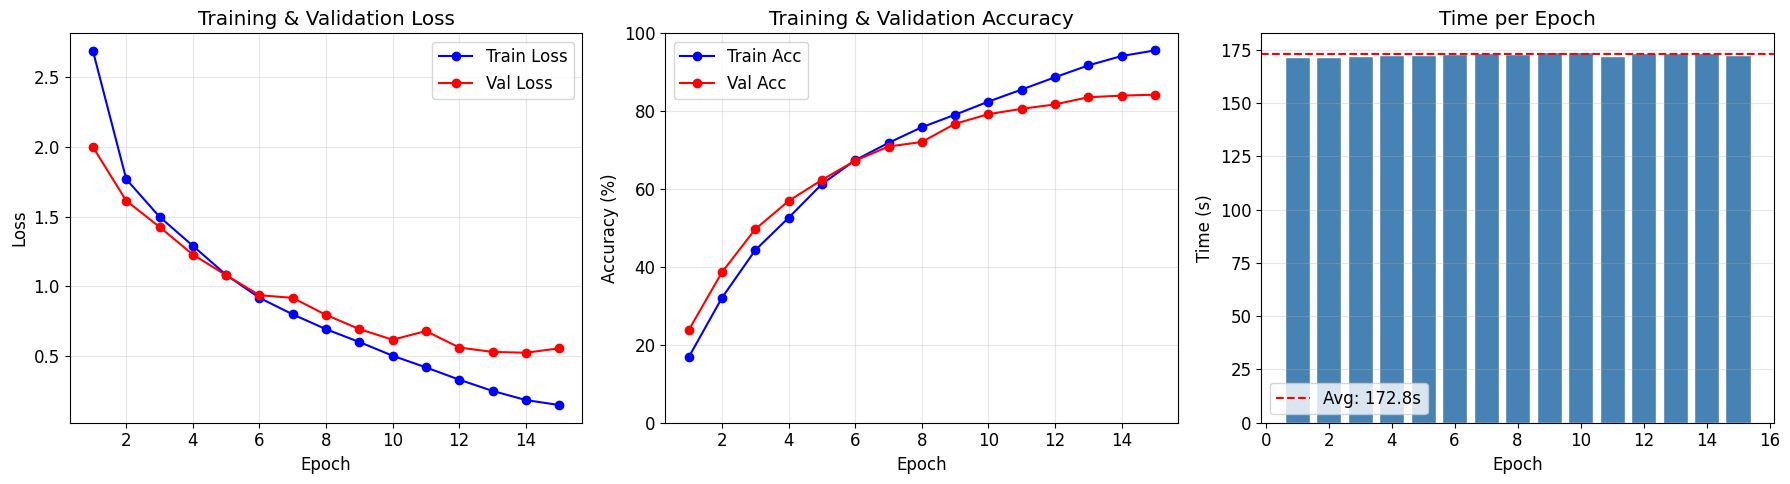

图表已保存至: /home/ma-user/work/data/training_curves.png


In [14]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss 曲线
axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', markersize=6)
axes[0].plot(epochs, history['val_loss'], 'r-o', label='Val Loss', markersize=6)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy 曲线
axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train Acc', markersize=6)
axes[1].plot(epochs, history['val_acc'], 'r-o', label='Val Acc', markersize=6)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 100])

# Epoch 耗时
axes[2].bar(epochs, history['epoch_time'], color='steelblue', edgecolor='white')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Time (s)')
axes[2].set_title('Time per Epoch')
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].axhline(y=sum(history['epoch_time'])/len(history['epoch_time']), 
                color='red', linestyle='--', label=f"Avg: {sum(history['epoch_time'])/len(history['epoch_time']):.1f}s")
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{DATA_ROOT}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"图表已保存至: {DATA_ROOT}/training_curves.png")

## 7. 对比：CPU 上一个 batch 的耗时

In [15]:
cpu_device = torch.device('cpu')
model_cpu = build_model().to(cpu_device)
cpu_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)

model_cpu.train()
opt_cpu = optim.SGD(model_cpu.parameters(), lr=0.001, momentum=0.9)

t0 = time.time()
for i, (inputs, labels) in enumerate(cpu_loader):
    if i >= 5:
        break
    inputs, labels = inputs.to(cpu_device), labels.to(cpu_device)
    opt_cpu.zero_grad()
    outputs = model_cpu(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    opt_cpu.step()
cpu_time_per_batch = (time.time() - t0) / 5

# NPU 同样 5 个 batch
model_npu.train()
npu_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)

t0 = time.time()
for i, (inputs, labels) in enumerate(npu_loader):
    if i >= 5:
        break
    inputs, labels = inputs.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model_npu(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
torch_npu.npu.synchronize()
npu_time_per_batch = (time.time() - t0) / 5

print(f"CPU 单 batch (64) 耗时: {cpu_time_per_batch:.1f}s")
print(f"NPU 单 batch (64) 耗时: {npu_time_per_batch:.1f}s")
print(f"NPU 训练加速比:            {cpu_time_per_batch / npu_time_per_batch:.1f}x")

CPU 单 batch (64) 耗时: 53.5s
NPU 单 batch (64) 耗时: 0.4s
NPU 训练加速比:            127.6x


## 8. 结果汇总

In [16]:
print("=" * 60)
print("【ResNet-50 + CIFAR-10 训练结果汇总】")
print("-" * 60)
print(f"设备:              {torch.npu.get_device_name(0)}")
print(f"模型:              ResNet-50 (from scratch)")
print(f"数据集:            CIFAR-10 (50k train / 10k val)")
print(f"训练轮数:          {NUM_EPOCHS} epochs")
print(f"batch size:        128")
print(f"总训练时间:        {total_time:.1f}s ({total_time/60:.1f}min)")
print(f"最佳验证准确率:     {best_acc:.2f}%")
print(f"最终训练准确率:     {history['train_acc'][-1]:.2f}%")
print(f"最终验证准确率:     {history['val_acc'][-1]:.2f}%")
print(f"平均 epoch 耗时:    {sum(history['epoch_time'])/len(history['epoch_time']):.1f}s")
print(f"CPU batch(64)耗时:  {cpu_time_per_batch:.1f}s")
print(f"NPU batch(64)耗时:  {npu_time_per_batch:.1f}s")
print(f"NPU vs CPU 加速:    {cpu_time_per_batch/npu_time_per_batch:.1f}x")
print("=" * 60)

【ResNet-50 + CIFAR-10 训练结果汇总】
------------------------------------------------------------
设备:              Ascend910B4
模型:              ResNet-50 (from scratch)
数据集:            CIFAR-10 (50k train / 10k val)
训练轮数:          15 epochs
batch size:        128
总训练时间:        2599.3s (43.3min)
最佳验证准确率:     84.25%
最终训练准确率:     95.62%
最终验证准确率:     84.25%
平均 epoch 耗时:    172.8s
CPU batch(64)耗时:  53.5s
NPU batch(64)耗时:  0.4s
NPU vs CPU 加速:    127.6x
